In [1]:
# Import libraries
import rapids_singlecell as rsc
import scanpy as sc
import cupy as cp
import numpy as np
import pandas as pd
import anndata
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from scipy.stats import pearsonr
from scipy.sparse import issparse 

# Set seed
np.random.seed(712)

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column width
pd.set_option("display.max_colwidth", None)

base_dir = "/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/"

/opt/conda/lib/python3.13/site-packages/cudf/utils/gpu_utils.py:162: UserWarning: No NVIDIA GPU detected
  warnings.warn("No NVIDIA GPU detected")
/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### UPDATING METRICS BASED ON PRIME VS V1 

In [23]:
adata = sc.read_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_unfiltered_joined_2025_11_05.h5ad")

In [25]:
adata.X.data

array([1., 1., 1., ..., 1., 1., 1.], shape=(109872444,))

In [48]:
# Gene x cell metrics for V1 
pattern = "-prime-with-v1-seg"
gene_mask_prime_seg = adata.var_names.str.contains(pattern, regex=True)

adata.obs["n_counts_prime_with_v1_seg"] = adata[:, gene_mask_prime_seg].X.sum(axis=1).A1
adata.obs["n_genes_prime_with_v1_seg"] = (adata[:, gene_mask_prime_seg].X > 0).sum(axis=1).A1

# Gene x cell metrics for prime
pattern = "-v1-prime"
gene_mask_v1 = adata.var_names.str.contains(pattern, regex=True)

adata.obs["n_counts_v1_prime"] = adata[:, gene_mask_v1].X.sum(axis=1).A1
adata.obs["n_genes_v1_prime"] = (adata[:, gene_mask_v1].X > 0).sum(axis=1).A1

# Both
adata.obs["n_counts_combined"] = adata.X.sum(axis=1).A1
adata.obs["n_genes_combined"] = (adata.X > 0).sum(axis=1).A1

adata.obs = adata.obs.drop(['nCount_RNA', 'nFeature_RNA'], axis=1)

# Adjust columns
new_order = ["matched_cell_ids", 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 
             'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 
             'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'cell_id_original_prime_v1_seg']
adata.obs = adata.obs.loc[:, new_order]

In [32]:
adata.X

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 109872444 stored elements and shape (1081011, 5481)>

In [5]:
adata.X.data

array([1., 1., 1., ..., 1., 1., 1.], shape=(109872444,))

### SAMPLE SPLITTING 

In [49]:
base_dir = "/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/cell_stats/"
cell_stats = sorted(glob.glob(os.path.join(base_dir, "**", "*_prime_with_V1_segmentation_cells_stats.csv"), recursive=True))

In [6]:
cell_stats

['/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL018D_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL026A_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL029A_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL031A_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL032D_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL033T_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL034D_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats

In [50]:
all_cell_stats = []

for f in cell_stats:
    filename = Path(f).name
    
    parts = filename.split('_') 

    if filename.startswith("PDLTMA"):
        try:
            sample_name = parts[1]
            tma_name = parts[0] 
        except IndexError:
            print(f"Skipping file due to unexpected name format: {filename}")
            continue # Skip to the next file
            
        df = pd.read_csv(f, skiprows=2)
        df["sample"] = sample_name
        df["tma"] = tma_name
        all_cell_stats.append(df)

# Combine everything into one DataFrame
cell_stats_df = pd.concat(all_cell_stats, ignore_index=True)

# # Adding TMA name to cell_id
# cell_stats_df["Cell ID"] = cell_stats_df["tma"] + "_" + cell_stats_df["Cell ID"].astype(str)

# Rename cell id column name to match metadata
cell_stats_df_new = cell_stats_df.rename(columns={"Cell ID": "cell_id"})

In [ ]:
cell_stats_df_new.head()

In [ ]:
# Checking common IDs  
common_ids = set(adata.obs["cell_id_original_prime_v1_seg"]) & set(cell_stats_df_new["cell_id"])
print("Number of overlapping cell_ids:", len(common_ids))

only_in_adata = set(adata.obs["cell_id_original_prime_v1_seg"]) - set(cell_stats_df_new["cell_id"])
only_in_meta = set(cell_stats_df_new["cell_id"]) - set(adata.obs["cell_id_original_prime_v1_seg"])
print("Cells only in adata_filtered_combined.obs:", len(only_in_adata))
print("Cells only in cell_stats:", len(only_in_meta))

In [51]:
# Ensure cell_id → sample mapping is unique
sample_df = cell_stats_df_new[['cell_id', 'sample']].drop_duplicates(subset='cell_id').set_index('cell_id')

# Add sample column aligned to all three adata objects, fill missing with "UNSURE"
adata.obs.set_index('cell_id_original_prime_v1_seg', inplace=True)
adata.obs['sample'] = sample_df.reindex(adata.obs.index)['sample'].fillna('UNSURE')

In [52]:
# Add spatial coordinates from metadata
coords = adata.obs[["x_centroid_v1_prime", "y_centroid_v1_prime"]].values  # shape (n_obs, 2)
adata.obsm["spatial"] = coords

# Add coordinates into obs from obsm
adata.obs['x_centroid_v1_prime'] = adata.obsm['spatial'][:, 0]
adata.obs['y_centroid_v1_prime'] = adata.obsm['spatial'][:, 1]

# Check
print(adata.obsm["spatial"].shape)

(1081011, 2)


In [53]:
## Save raw counts here!
adata.layers['counts'] = adata.X.copy()

In [54]:
adata.X.data

array([1., 1., 1., ..., 1., 1., 1.], shape=(109872444,))

In [55]:
adata_test = sc.pp.log1p(adata, copy=True)

In [62]:
adata_test.X.data

array([0.69314718, 0.69314718, 0.69314718, ..., 0.69314718, 0.69314718,
       0.69314718], shape=(109872444,))

In [63]:
adata_test.write_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_allgenes_unfiltered_split_2025_12_07.h5ad")

... storing 'sample' as categorical


In [66]:
adata_test.X.data

array([0.69314718, 0.69314718, 0.69314718, ..., 0.69314718, 0.69314718,
       0.69314718], shape=(109872444,))

### QC AND FILTERING 

In [26]:
adata = sc.read_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_allgenes_unfiltered_split_2025_12_07.h5ad")

In [27]:
adata

AnnData object with n_obs × n_vars = 1081011 × 5481
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample'
    var: 'name'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts'

In [65]:
adata.X.data

array([0.69314718, 0.69314718, 0.69314718, ..., 0.69314718, 0.69314718,
       0.69314718], shape=(109872444,))

In [17]:
adata.obs.head()

,matched_cell_ids,x_centroid_v1_prime,y_centroid_v1_prime,x_centroid_prime_v1_seg,y_centroid_prime_v1_seg,transcript_counts_v1_prime,transcript_counts_prime_v1_seg,cell_area,nucleus_area,nucleus_count,n_counts_prime_with_v1_seg,n_genes_prime_with_v1_seg,n_counts_v1_prime,n_genes_v1_prime,n_counts_combined,n_genes_combined,cell_id_original_v1_prime,sample
cell_id_original_prime_v1_seg,,,,,,,,,,,,,,,,,,
aaaablnp-1,aaaaaa,4249.194336,869.719849,4272.355957,864.619873,243,348,52.652189,30.615939,1,175.0,152,146.0,75,321.0,227,aaaacjpc-1,PDL095D
aaaabpoe-1,aaaaab,4239.613770,902.530823,4262.776367,897.430786,305,464,84.261566,29.757970,1,131.0,111,119.0,63,250.0,174,aaaacmjh-1,PDL095D
aaaacapp-1,aaaaac,4226.944336,921.231018,4249.974121,916.132324,667,1149,141.835786,44.162814,1,343.0,283,233.0,98,576.0,381,aaaafpja-1,PDL095D
aaaacmkn-1,aaaaae,4232.353516,919.322571,4255.381348,914.224731,218,339,49.852502,31.925470,1,193.0,170,143.0,62,336.0,232,aaaahipk-1,PDL095D
aaaadecf-1,aaaaaf,4246.328613,882.128601,4269.491699,877.028625,171,205,50.936252,33.867189,1,116.0,104,105.0,63,221.0,167,aaaahlpa-1,PDL095D


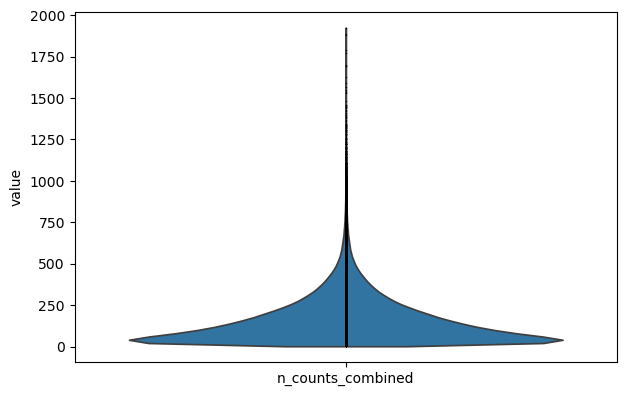

In [15]:
sc.pl.violin(
    adata,
    ["n_counts_combined"],
    jitter=0
)

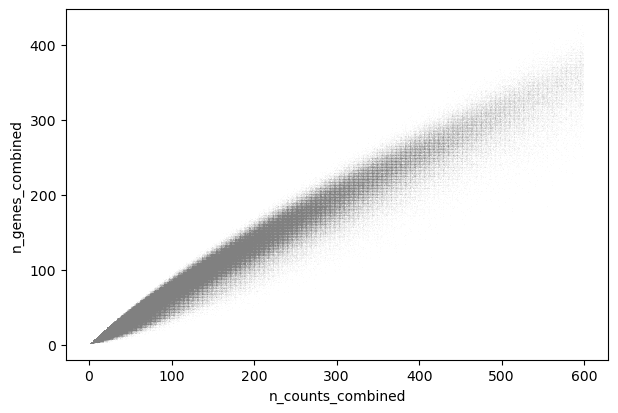

In [36]:
sc.pl.scatter(adata[adata.obs["n_counts_combined"] < 600, :],
              "n_counts_combined", 
              "n_genes_combined"
             )

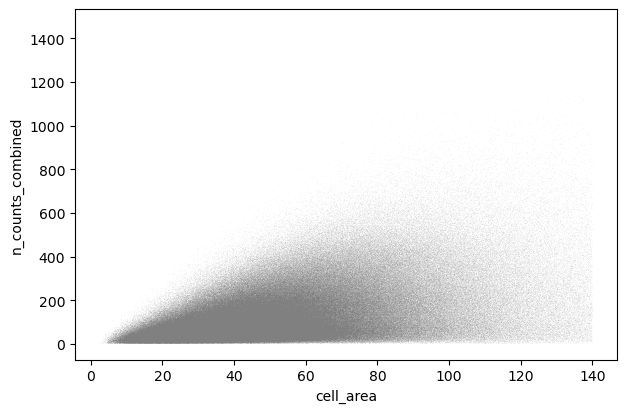

In [44]:
# Filter out cell_area < 5.0 & > 140
sc.pl.scatter(adata[adata.obs["cell_area"] < 140, :],
              "cell_area", 
              "n_counts_combined"
             )

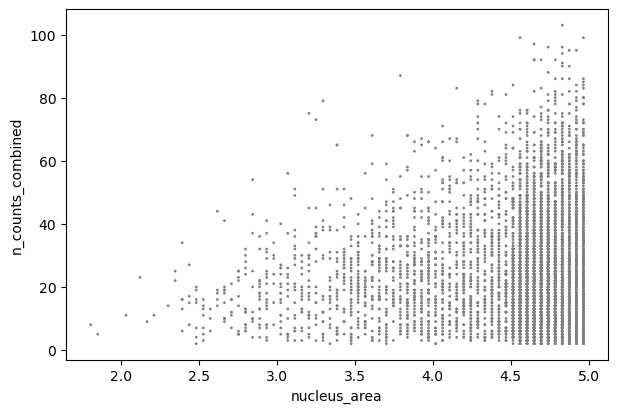

In [47]:
# Filter out nucleus_area < 3
sc.pl.scatter(adata[adata.obs["nucleus_area"] < 5, :],
              "nucleus_area", 
              "n_counts_combined"
             )

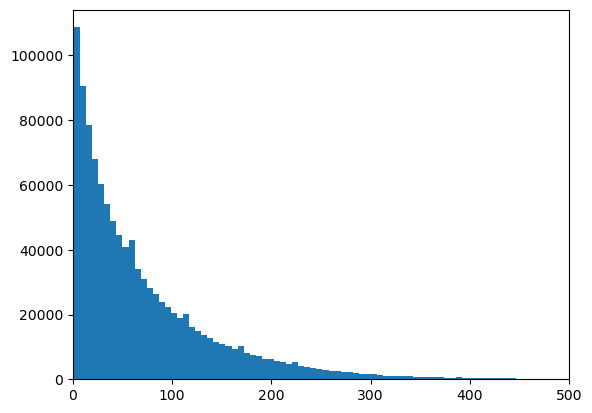

In [15]:
# # Filter out n_counts_combined < 10
# plt.hist(adata.obs["n_counts_combined"], bins=100)
# plt.xlim(0, 20)
# plt.show()

# # Filter out n_counts_v1 < 10
# plt.hist(adata.obs["n_counts_v1_prime"], bins=100)
# plt.xlim(0, 20)
# plt.show()

# Filter out n_counts_prime < 12
plt.hist(adata.obs["n_counts_prime_with_v1_seg"], bins=200)
plt.xlim(0, 500)
plt.show()

In [16]:
counts = adata.obs['n_counts_v1_prime'] < 50
print(counts.value_counts())

n_counts_v1_prime
False    664772
True     416239
Name: count, dtype: int64


In [11]:
adata.obs.groupby(['sample']).size()

/tmp/ipykernel_4165099/3827868359.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(['sample']).size()


sample
PDL018D     60113
PDL026A     54095
PDL029A     29232
PDL031A     53161
PDL032D     75328
PDL033T      6264
PDL034D    140078
PDL040A     43496
PDL042D     19098
PDL047T     20259
PDL055T     23157
PDL061      38055
PDL072      69103
PDL077      46331
PDL085A     28723
PDL095D     99992
PDL097       8645
UNSURE        720
dtype: int64

In [67]:
adata_filtered_combined = adata[adata.obs['n_counts_combined'] >= 50]
adata_filtered_combined = adata_filtered_combined[adata_filtered_combined.obs['n_genes_combined'] >= 5]
adata_filtered_combined = adata_filtered_combined[adata_filtered_combined.obs['cell_area'] >= 5]
adata_filtered_combined = adata_filtered_combined[adata_filtered_combined.obs['cell_area'] <= 140]
adata_filtered_combined = adata_filtered_combined[adata_filtered_combined.obs['nucleus_area'] >= 3].copy()

In [69]:
adata_filtered_combined.write_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_allgenes_filtered_split_2025_12_07.h5ad")

In [70]:
adata.var["is_v1_gene"] = gene_mask_v1
adata_v1 = adata[:, adata.var["is_v1_gene"]].copy()

adata_filtered_v1 = adata_v1[adata_v1.obs['n_counts_v1_prime'] >= 50]
adata_filtered_v1 = adata_filtered_v1[adata_filtered_v1.obs['n_genes_combined'] >= 5]
adata_filtered_v1 = adata_filtered_v1[adata_filtered_v1.obs['cell_area'] >= 5]
adata_filtered_v1 = adata_filtered_v1[adata_filtered_v1.obs['cell_area'] <= 140]
adata_filtered_v1 = adata_filtered_v1[adata_filtered_v1.obs['nucleus_area'] >= 3].copy()

In [71]:
adata_filtered_v1.write_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_v1genes_filtered_split_2025_12_07.h5ad")

In [72]:
adata.var["is_prime_gene"] = gene_mask_prime_seg
adata_prime = adata[:, adata.var["is_prime_gene"]].copy()

adata_filtered_prime = adata_prime[adata_prime.obs['n_counts_prime_with_v1_seg'] >= 50]
adata_filtered_prime = adata_filtered_prime[adata_filtered_prime.obs['n_genes_combined'] >= 5]
adata_filtered_prime = adata_filtered_prime[adata_filtered_prime.obs['cell_area'] >= 5]
adata_filtered_prime = adata_filtered_prime[adata_filtered_prime.obs['cell_area'] <= 140]
adata_filtered_prime = adata_filtered_prime[adata_filtered_prime.obs['nucleus_area'] >= 3].copy()

In [73]:
adata_filtered_prime.write_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_primegenes_filtered_split_2025_12_07.h5ad")

In [31]:
test_split = sc.read_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_allgenes_filtered_split_2025_12_07.h5ad")

### CLUSTERING ALL THREE PANEL ITERATIONS

In [28]:
adata_filtered_v1 = sc.read_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_v1genes_20pcs_2025_12_02.h5ad")

In [33]:
adata_filtered_v1

AnnData object with n_obs × n_vars = 644069 × 480
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample', 'leiden_0.5_v1', 'leiden_1.0_v1'
    var: 'name', 'is_v1_gene'
    uns: 'leiden_0.5_v1', 'leiden_1.0_v1', 'leiden_1.0_v1_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [47]:
## Figure 2B - bar charts pre/post-filtering
from plotnine import (
    ggplot,
    aes,
    geom_bar,
    labs,
    theme_minimal,
    theme,
    element_text
)

# Compiling all counts across all objects into one df
raw_data = {
    'Unfiltered': [1081011],
    'Filtered (combined)': [815850],
    'Filtered (V1)': [644069],
    'Filtered (Prime)': [510205]
}

stages = list(raw_data.keys())
counts = [v[0] for v in raw_data.values()]

# Long-wise format
plot_df = pd.DataFrame({
    'Filtering_Stage': stages,
    'Count': counts
})

plot_df['Filtering_Stage'] = pd.Categorical(
    plot_df['Filtering_Stage'], 
    categories=stages, 
    ordered=True
)

# Export to csv to plot in R
plot_df_save = pd.DataFrame.to_csv(plot_df, "/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/cell_counts_prepostfiltering.csv")

In [29]:
print(plot_df)

{'Pre-filtering': [1081011], 'Post-filtering (V1)': [644069], 'Post-filtering (Prime)': [510205], 'Post-filtering (Combined)': [815850]}


2025-12-09 16:53:54 | [INFO] init


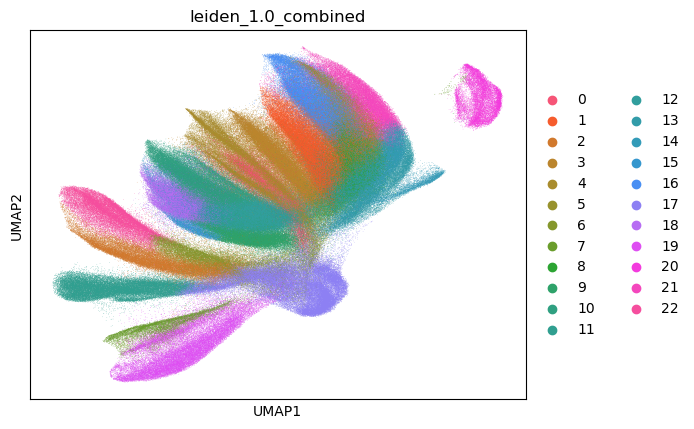

In [74]:
## Combined anndata object

# GPU pipeline
rsc.get.anndata_to_GPU(adata_filtered_combined)

# Log transform
rsc.pp.log1p(adata_filtered_combined)

# Run PCA
rsc.tl.pca(adata_filtered_combined, n_comps=20)

# Send adata object back to CPU.
rsc.get.anndata_to_CPU(adata_filtered_combined)

rsc.pp.neighbors(adata_filtered_combined, n_neighbors=15, use_rep='X_pca')
rsc.tl.umap(adata_filtered_combined)

#Leiden clustering, add resolutions as needed.
rsc.tl.leiden(adata_filtered_combined, resolution=0.5, key_added="leiden_0.5_combined")
rsc.tl.leiden(adata_filtered_combined, resolution=1.0, key_added="leiden_1.0_combined")

# Generate a palette with enough distinct colors for your clusters
n_clusters = adata_filtered_combined.obs['leiden_1.0_combined'].nunique()
palette = sns.husl_palette(n_clusters, l=0.6, s=0.9)

sc.pl.umap(
    adata_filtered_combined,
    color="leiden_1.0_combined",
    palette=palette,
    s=0.5
)

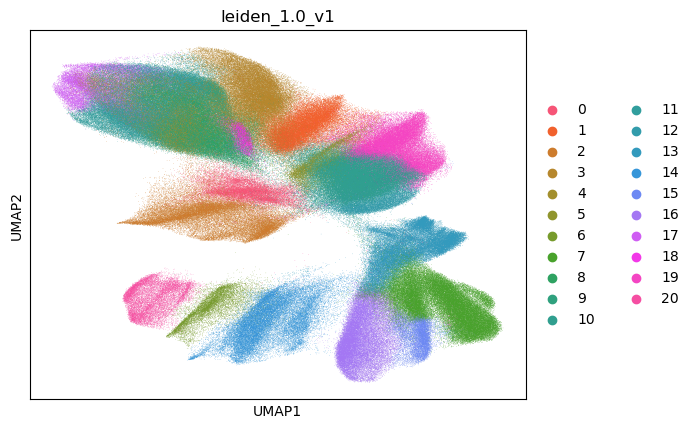

In [76]:
## V1 anndata object

# GPU pipeline
rsc.get.anndata_to_GPU(adata_filtered_v1)

# Log transform
rsc.pp.log1p(adata_filtered_v1)

# Run PCA
rsc.tl.pca(adata_filtered_v1, n_comps=20)

# Send adata object back to CPU.
rsc.get.anndata_to_CPU(adata_filtered_v1)

rsc.pp.neighbors(adata_filtered_v1, n_neighbors=15, use_rep='X_pca')
rsc.tl.umap(adata_filtered_v1)

#Leiden clustering, add resolutions as needed.
rsc.tl.leiden(adata_filtered_v1, resolution=0.5, key_added="leiden_0.5_v1")
rsc.tl.leiden(adata_filtered_v1, resolution=1.0, key_added="leiden_1.0_v1")

# Generate a palette with enough distinct colors for your clusters
n_clusters = adata_filtered_v1.obs['leiden_1.0_v1'].nunique()
palette = sns.husl_palette(n_clusters, l=0.6, s=0.9)

sc.pl.umap(
    adata_filtered_v1,
    color="leiden_1.0_v1",
    palette=palette,
    s=0.5
)

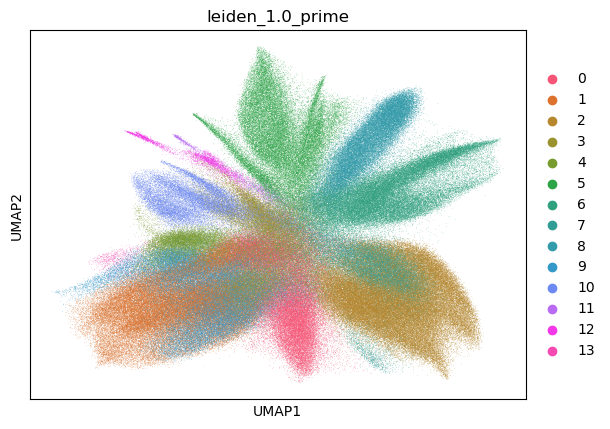

In [77]:
## Prime anndata object

# GPU pipeline
rsc.get.anndata_to_GPU(adata_filtered_prime)

# Log transform
rsc.pp.log1p(adata_filtered_prime)

# Run PCA
rsc.tl.pca(adata_filtered_prime, n_comps=50)

# Send adata object back to CPU.
rsc.get.anndata_to_CPU(adata_filtered_prime)

rsc.pp.neighbors(adata_filtered_prime, n_neighbors=15, use_rep='X_pca')
rsc.tl.umap(adata_filtered_prime)

#Leiden clustering, add resolutions as needed.
rsc.tl.leiden(adata_filtered_prime, resolution=0.5, key_added="leiden_0.5_prime")
rsc.tl.leiden(adata_filtered_prime, resolution=1.0, key_added="leiden_1.0_prime")

# Generate a palette with enough distinct colors for your clusters
n_clusters = adata_filtered_prime.obs['leiden_1.0_prime'].nunique()
palette = sns.husl_palette(n_clusters, l=0.6, s=0.9)

sc.pl.umap(
    adata_filtered_prime,
    color="leiden_1.0_prime",
    palette=palette,
    s=0.5
)

In [79]:
adata_filtered_combined.write_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_allgenes_20pcs_2025_12_02.h5ad")

In [80]:
adata_filtered_v1.write_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_v1genes_20pcs_2025_12_02.h5ad")

In [ ]:
adata_filtered_prime.write_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_primegenes_combined_20pcs_2025_12_02.h5ad")

### MAPPING IDS FROM EACH OBJECT TO THE OTHERS

In [34]:
adata_filtered_combined = sc.read_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_allgenes_20pcs_2025_12_02.h5ad")
adata_filtered_v1 = sc.read_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_v1genes_20pcs_2025_12_02.h5ad")
adata_filtered_prime = sc.read_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_primegenes_combined_20pcs_2025_12_02.h5ad")

In [82]:
# Isolating clustering columns
combined_meta = adata_filtered_combined.obs
v1_meta = adata_filtered_v1.obs
prime_meta = adata_filtered_prime.obs

combined_clustering = combined_meta[["matched_cell_ids", "leiden_0.5_combined", "leiden_1.0_combined"]]
v1_clustering = v1_meta[["matched_cell_ids", "leiden_0.5_v1", "leiden_1.0_v1"]]
prime_clustering = prime_meta[["matched_cell_ids", "leiden_0.5_prime", "leiden_1.0_prime"]]

columns_for_combined_meta = pd.merge(
    v1_clustering,
    prime_clustering,
    on='matched_cell_ids',
    how='left'
)

columns_for_v1_meta = pd.merge(
    combined_clustering,
    prime_clustering,
    on='matched_cell_ids',
    how='left'
)

columns_for_prime_meta = pd.merge(
    v1_clustering,
    combined_clustering,
    on='matched_cell_ids',
    how='left'
)

# Appending them to metadata
combined_meta_new = combined_meta.merge(
    columns_for_combined_meta, 
    on='matched_cell_ids',                
    how='left'                   
)

v1_meta_new = v1_meta.merge(
    columns_for_v1_meta, 
    on='matched_cell_ids',                
    how='left'                   
)

prime_meta_new = prime_meta.merge(
    columns_for_prime_meta, 
    on='matched_cell_ids',                
    how='left'                   
)

# Add new metadata into each anndata object
combined_meta_new.set_index('matched_cell_ids', inplace=True)
adatas_obs_index = adata_filtered_combined.obs.index
combined_meta_new_aligned = combined_meta_new.reindex(adatas_obs_index)

for col in ['leiden_0.5_v1', 'leiden_1.0_v1', 'leiden_0.5_prime', 'leiden_1.0_prime']:
    adata_filtered_combined.obs[col] = combined_meta_new_aligned[col]

v1_meta_new.set_index('matched_cell_ids', inplace=True)
adatas_obs_index = adata_filtered_v1.obs.index
v1_meta_new_aligned = v1_meta_new.reindex(adatas_obs_index)

for col in ['leiden_0.5_combined', 'leiden_1.0_combined', 'leiden_0.5_prime', 'leiden_1.0_prime']:
    adata_filtered_v1.obs[col] = v1_meta_new_aligned[col]

prime_meta_new.set_index('matched_cell_ids', inplace=True)
adatas_obs_index = adata_filtered_prime.obs.index
prime_meta_new_aligned = prime_meta_new.reindex(adatas_obs_index)

for col in ['leiden_0.5_v1', 'leiden_1.0_v1', 'leiden_0.5_combined', 'leiden_1.0_combined']:
    adata_filtered_prime.obs[col] = prime_meta_new_aligned[col]

In [84]:
# Check the new columns
print(adata_filtered_prime.obs[['matched_cell_ids', 'leiden_0.5_combined']].tail())

                              matched_cell_ids leiden_0.5_combined
cell_id_original_prime_v1_seg                                     
oilpbpek-1                              aclahu                 NaN
oilpcfmk-1                              aclahv                 NaN
oilpnakb-1                              aclain                 NaN
oimagjja-1                              aclaiw                 NaN
oimagnca-1                              aclaix                 NaN


### RE-IDENTIFYING SAMPLES  

In [ ]:
adata_filtered_combined = sc.read_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_allgenes_20pcs_2025_12_02.h5ad")
adata_filtered_v1 = sc.read_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_v1genes_20pcs_2025_12_02.h5ad")
adata_filtered_prime = sc.read_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_primegenes_combined_50pcs_2025_12_02.h5ad")

In [35]:
base_dir = "/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/"
cell_stats = sorted(glob.glob(os.path.join(base_dir, "**", "*_prime_with_V1_segmentation_cells_stats.csv"), recursive=True))

In [36]:
cell_stats

['/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL018D_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL026A_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL029A_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL031A_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL032D_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL033T_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats/PDLTMA006_PDL034D_prime_with_V1_segmentation_cells_stats.csv',
 '/scratch/smallapragada/bbl_project/v1_prime5k_comparison/cell_stats

In [37]:
all_cell_stats = []

for f in cell_stats:
    filename = Path(f).name
    
    parts = filename.split('_') 

    if filename.startswith("PDLTMA"):
        try:
            sample_name = parts[1]
            tma_name = parts[0] 
        except IndexError:
            print(f"Skipping file due to unexpected name format: {filename}")
            continue # Skip to the next file
            
        df = pd.read_csv(f, skiprows=2)
        df["sample"] = sample_name
        df["tma"] = tma_name
        all_cell_stats.append(df)

# Combine everything into one DataFrame
cell_stats_df = pd.concat(all_cell_stats, ignore_index=True)

# # Adding TMA name to cell_id
# cell_stats_df["Cell ID"] = cell_stats_df["tma"] + "_" + cell_stats_df["Cell ID"].astype(str)

# Rename cell id column name to match metadata
cell_stats_df_new = cell_stats_df.rename(columns={"Cell ID": "cell_id"})

In [38]:
cell_stats_df_new.head()

,cell_id,Cluster,Transcripts,Area (µm^2),sample,tma
0,ocklcjdi-1,Cluster 1,0,109.05,PDL018D,PDLTMA006
1,ngeaaace-1,Cluster 6,0,75.00,PDL018D,PDLTMA006
2,ngdpolkl-1,Cluster 6,0,25.74,PDL018D,PDLTMA006
3,oiiefooi-1,Cluster 1,0,138.95,PDL018D,PDLTMA006
4,oiiggbon-1,Cluster 2,0,114.88,PDL018D,PDLTMA006


In [39]:
# Checking common IDs  
common_ids = set(adata_filtered_combined.obs["cell_id_original_prime_v1_seg"]) & set(cell_stats_df_new["cell_id"])
print("Number of overlapping cell_ids:", len(common_ids))

only_in_adata = set(adata_filtered_combined.obs["cell_id_original_prime_v1_seg"]) - set(cell_stats_df_new["cell_id"])
only_in_meta = set(cell_stats_df_new["cell_id"]) - set(adata_filtered_combined.obs["cell_id_original_prime_v1_seg"])
print("Cells only in adata_filtered_combined.obs:", len(only_in_adata))
print("Cells only in cell_stats:", len(only_in_meta))

Number of overlapping cell_ids: 815130
Cells only in adata_filtered_combined.obs: 720
Cells only in cell_stats: 291376


In [40]:
adata_filtered_combined.obs.head()

,matched_cell_ids,x_centroid_v1_prime,y_centroid_v1_prime,x_centroid_prime_v1_seg,y_centroid_prime_v1_seg,transcript_counts_v1_prime,transcript_counts_prime_v1_seg,cell_area,nucleus_area,nucleus_count,n_counts_prime_with_v1_seg,n_genes_prime_with_v1_seg,n_counts_v1_prime,n_genes_v1_prime,n_counts_combined,n_genes_combined,cell_id_original_v1_prime,cell_id_original_prime_v1_seg,leiden_0.5_combined,leiden_1.0_combined
aaaaaa,aaaaaa,4249.194336,869.719849,4272.355957,864.619873,243,348,52.652189,30.615939,1,175.0,152,146.0,75,321.0,227,aaaacjpc-1,aaaablnp-1,9,18
aaaaab,aaaaab,4239.613770,902.530823,4262.776367,897.430786,305,464,84.261566,29.757970,1,131.0,111,119.0,63,250.0,174,aaaacmjh-1,aaaabpoe-1,9,18
aaaaae,aaaaae,4232.353516,919.322571,4255.381348,914.224731,218,339,49.852502,31.925470,1,193.0,170,143.0,62,336.0,232,aaaahipk-1,aaaacmkn-1,9,18
aaaaaf,aaaaaf,4246.328613,882.128601,4269.491699,877.028625,171,205,50.936252,33.867189,1,116.0,104,105.0,63,221.0,167,aaaahlpa-1,aaaadecf-1,9,18
aaaaag,aaaaag,4240.083496,895.409424,4263.248535,890.309448,319,394,76.946253,49.942814,1,233.0,195,196.0,95,429.0,290,aaaailkd-1,aaaadlnm-1,9,18


In [41]:
# Ensure cell_id → sample mapping is unique
sample_df = cell_stats_df_new[['cell_id', 'sample']].drop_duplicates(subset='cell_id').set_index('cell_id')

# Add sample column aligned to all three adata objects, fill missing with "UNSURE"
adata_filtered_combined.obs.set_index('cell_id_original_prime_v1_seg', inplace=True)
adata_filtered_combined.obs['sample'] = sample_df.reindex(adata_filtered_combined.obs.index)['sample'].fillna('UNSURE')

adata_filtered_v1.obs.set_index('cell_id_original_prime_v1_seg', inplace=True)
adata_filtered_v1.obs['sample'] = sample_df.reindex(adata_filtered_v1.obs.index)['sample'].fillna('UNSURE')

adata_filtered_prime.obs.set_index('cell_id_original_prime_v1_seg', inplace=True)
adata_filtered_prime.obs['sample'] = sample_df.reindex(adata_filtered_prime.obs.index)['sample'].fillna('UNSURE')

In [42]:
adata_filtered_v1.obs.groupby(['sample']).size()

sample
PDL018D     53432
PDL026A     37064
PDL029A     24750
PDL031A     36881
PDL032D     52437
PDL033T      5114
PDL034D    113592
PDL040A     32451
PDL042D     12818
PDL047T     14054
PDL055T     20218
PDL061      33318
PDL072      63222
PDL077      39995
PDL085A     17553
PDL095D     79370
PDL097       7263
UNSURE        537
dtype: int64

In [43]:
## combined object

# Add spatial coordinates from metadata
coords = adata_filtered_combined.obs[["x_centroid_v1_prime", "y_centroid_v1_prime"]].values  # shape (n_obs, 2)
adata_filtered_combined.obsm["spatial"] = coords

# Add coordinates into obs from obsm
adata_filtered_combined.obs['x_centroid_v1_prime'] = adata_filtered_combined.obsm['spatial'][:, 0]
adata_filtered_combined.obs['y_centroid_v1_prime'] = adata_filtered_combined.obsm['spatial'][:, 1]

# Check
print(adata_filtered_combined.obsm["spatial"].shape)

## V1 object

# Add spatial coordinates from metadata
coords = adata_filtered_v1.obs[["x_centroid_v1_prime", "y_centroid_v1_prime"]].values  # shape (n_obs, 2)
adata_filtered_v1.obsm["spatial"] = coords

# Add coordinates into obs from obsm
adata_filtered_v1.obs['x_centroid_v1_prime'] = adata_filtered_v1.obsm['spatial'][:, 0]
adata_filtered_v1.obs['y_centroid_v1_prime'] = adata_filtered_v1.obsm['spatial'][:, 1]

# Check
print(adata_filtered_v1.obsm["spatial"].shape)

## Prime object

# Add spatial coordinates from metadata
coords = adata_filtered_prime.obs[["x_centroid_v1_prime", "y_centroid_v1_prime"]].values  # shape (n_obs, 2)
adata_filtered_prime.obsm["spatial"] = coords

# Add coordinates into obs from obsm
adata_filtered_prime.obs['x_centroid_v1_prime'] = adata_filtered_prime.obsm['spatial'][:, 0]
adata_filtered_prime.obs['y_centroid_v1_prime'] = adata_filtered_prime.obsm['spatial'][:, 1]

# Check
print(adata_filtered_prime.obsm["spatial"].shape)

(815850, 2)
(644069, 2)
(510205, 2)


In [12]:
adata_filtered_combined.write_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_allgenes_20pcs_filtered_split_2025_12_05.h5ad")

In [13]:
adata_filtered_v1.write_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_v1genes_20pcs_filtered_split_2025_12_05.h5ad")

In [14]:
adata_filtered_prime.write_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_primegenes_combined_50pcs_filtered_split_2025_12_05.h5ad")

In [6]:
adata = sc.read_h5ad("/scratch/smallapragada/bbl_project/v1_prime5k_comparison/objects/v1_prime_comparison_allgenes_filtered_split_2025_12_07.h5ad")

In [12]:
sample_to_plot = "PDL034A"
adata_subset = adata[adata.obs['sample'] == sample_to_plot, :].copy()

/tmp/ipykernel_4165099/1289851398.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


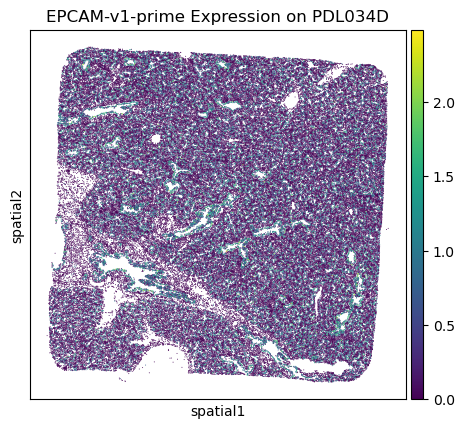

In [18]:
sc.pl.spatial(
    adata_subset, 
    color=['EPCAM-v1-prime'], 
    spot_size=10,
    title=f"EPCAM-v1-prime Expression on {sample_to_plot}"
)

### PLOTS

In [ ]:
## Figure 4A - UMAPs

# V1 plot

plt.style.use('seaborn-v0_8-white') 

clustering_cols = [
    "leiden_1.0_v1",
    "leiden_1.0_prime",
    "leiden_1.0_combined"
]

title_map = {
    "leiden_1.0_v1": "V1",
    "leiden_1.0_prime": "Prime",
    "leiden_1.0_combined": "Combined"
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(2.5, 6),
    facecolor='white'
)

axes = axes.flatten()

for i, col in enumerate(clustering_cols):
    n_clusters = adata_filtered_v1.obs[col].nunique()
    
    if n_clusters == 0:
        continue
        
    cmap = cm.get_cmap('tab20', n_clusters)
    palette = [cmap(j) for j in range(n_clusters)]

    sc.pl.umap(
        adata_filtered_v1,
        color=col,
        palette=palette,
        s=1, 
        ax=axes[i],
        show=False,
        title=title_map.get(col, col), 
        frameon=False 
    )
    
    ax = axes[i]
    
    ax.set_facecolor('white')
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_visible(True)
        
    ax.set_title(ax.get_title(), fontsize=7, fontweight='bold', pad=10, color='black')
    
    if ax.legend_ is not None:
        ax.legend_.remove()

plt.tight_layout()

output_path = "/home/smallapragada/v1_5K_panel_comparison_project/v1_umap_clustering_comparison.png"

fig.savefig(
    output_path, 
    format='png', 
    bbox_inches='tight',
    dpi=300
)

plt.show()

# Prime UMAP plots

plt.style.use('seaborn-v0_8-white') 

clustering_cols = [
    "leiden_1.0_v1",
    "leiden_1.0_prime",
    "leiden_1.0_combined"
]

title_map = {
    "leiden_1.0_v1": "V1",
    "leiden_1.0_prime": "Prime",
    "leiden_1.0_combined": "Combined"
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(2.5, 6),
    facecolor='white'
)

axes = axes.flatten()

for i, col in enumerate(clustering_cols):
    n_clusters = adata_filtered_prime.obs[col].nunique()
    
    if n_clusters == 0:
        continue
        
    cmap = cm.get_cmap('tab20', n_clusters)
    palette = [cmap(j) for j in range(n_clusters)]

    sc.pl.umap(
        adata_filtered_prime,
        color=col,
        palette=palette,
        s=1, 
        ax=axes[i],
        show=False,
        title=title_map.get(col, col), 
        frameon=False 
    )
    
    ax = axes[i]
    
    ax.set_facecolor('white')
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_visible(True)
        
    ax.set_title(ax.get_title(), fontsize=7, fontweight='bold', pad=10, color='black')
    
    if ax.legend_ is not None:
        ax.legend_.remove()

plt.tight_layout()

output_path = "/home/smallapragada/v1_5K_panel_comparison_project/prime_umap_clustering_comparison.png"

fig.savefig(
    output_path, 
    format='png', 
    bbox_inches='tight',
    dpi=300
)

plt.show()

# Combined plot

plt.style.use('seaborn-v0_8-white') 

clustering_cols = [
    "leiden_1.0_v1",
    "leiden_1.0_prime",
    "leiden_1.0_combined"
]

title_map = {
    "leiden_1.0_v1": "V1",
    "leiden_1.0_prime": "Prime",
    "leiden_1.0_combined": "Combined"
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(2.5, 6),
    facecolor='white'
)

axes = axes.flatten()

for i, col in enumerate(clustering_cols):
    n_clusters = adata_filtered_combined.obs[col].nunique()
    
    if n_clusters == 0:
        continue
        
    cmap = cm.get_cmap('tab20', n_clusters)
    palette = [cmap(j) for j in range(n_clusters)]

    sc.pl.umap(
        adata_filtered_combined,
        color=col,
        palette=palette,
        s=1, 
        ax=axes[i],
        show=False,
        title=title_map.get(col, col), 
        frameon=False 
    )
    
    ax = axes[i]
    
    ax.set_facecolor('white')
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_visible(True)
        
    ax.set_title(ax.get_title(), fontsize=7, fontweight='bold', pad=10, color='black')
    
    if ax.legend_ is not None:
        ax.legend_.remove()

plt.tight_layout()

output_path = "/home/smallapragada/v1_5K_panel_comparison_project/combined_umap_clustering_comparison.png"

fig.savefig(
    output_path, 
    format='png', 
    bbox_inches='tight',
    dpi=300
)

plt.show()

### SPLITTING DUAL OBJECT INTO EACH PANEL

In [34]:
adata_filtered_combined = sc.read_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_allgenes_20pcs_2025_12_02.h5ad")
adata_filtered_v1 = sc.read_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_v1genes_20pcs_2025_12_02.h5ad")
adata_filtered_prime = sc.read_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_primegenes_combined_20pcs_2025_12_02.h5ad")

In [18]:
adata_filtered_combined.var_names

Index(['ABHD16A-v1-prime', 'ACAA2-v1-prime', 'ACKR1-v1-prime',
       'ACSL3-v1-prime', 'ACTA2-v1-prime', 'ADAMTS1-v1-prime',
       'ADGRF5-v1-prime', 'ADGRL4-v1-prime', 'AGER-v1-prime', 'AGR3-v1-prime',
       ...
       'ZPR1-prime-with-v1-seg', 'ZSCAN1-prime-with-v1-seg',
       'ZSCAN12-prime-with-v1-seg', 'ZSCAN16-prime-with-v1-seg',
       'ZSCAN20-prime-with-v1-seg', 'ZSCAN26-prime-with-v1-seg',
       'ZSWIM6-prime-with-v1-seg', 'ZUP1-prime-with-v1-seg',
       'ZYG11B-prime-with-v1-seg', 'ZYX-prime-with-v1-seg'],
      dtype='object', length=5481)

In [28]:
# Combined object - V1 genes
mask_v1 = adata_filtered_combined.var_names.str.endswith('-v1-prime')
adata_filtered_combined_v1genesonly = adata_filtered_combined[:, mask_v1]

# Combined object - Prime genes
mask_prime = adata_filtered_combined.var_names.str.endswith('-prime-with-v1-seg')
adata_filtered_combined_primegenesonly = adata_filtered_combined[:, mask_prime]

In [29]:
# Removing string names so it's just the gene
adata_filtered_combined_v1genesonly.var_names = adata_filtered_combined_v1genesonly.var_names.str.replace('-v1-prime', '', regex=False)

adata_filtered_combined_primegenesonly.var_names = adata_filtered_combined_primegenesonly.var_names.str.replace('-prime-with-v1-seg', '', regex=False)

In [24]:
# Combined object - Prime genes and overlaps are V1-biased 
# Results in 5242 genes --> 5001 prime genes + 480 V1 genes - 239 overlapped genes

# Strip suffixes to get base gene names
base_names = adata_filtered_combined.var_names.str.replace('-v1-prime', '', regex=False).str.replace('-prime-with-v1-seg', '', regex=False)

# For duplicates, prefer -v1-prime over -prime-with-v1-seg
is_v1 = adata_filtered_combined.var_names.str.endswith('-v1-prime')

# Build a dataframe to resolve duplicates
df = pd.DataFrame({
    'original': adata_filtered_combined.var_names,
    'base': base_names,
    'is_v1': is_v1
})

# For each base gene, pick v1-prime if available, otherwise take what's there
idx_to_keep = (
    df.sort_values('is_v1', ascending=False) 
      .drop_duplicates('base', keep='first')
      .index
)

adata_filtered_combined_v1biased = adata_filtered_combined[:, idx_to_keep]

# Strip suffixes from var_names
adata_filtered_combined_v1biased.var_names = (
    adata_filtered_combined_v1biased.var_names
    .str.replace('-v1-prime', '', regex=False)
    .str.replace('-prime-with-v1-seg', '', regex=False)
)

In [33]:
adata_filtered_combined_v1genesonly.write_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/fishing_2lines_dualrun_v1_480genes_20pcs_2026_04_16.h5ad")
adata_filtered_combined_primegenesonly.write_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/fishing_2lines_dualrun_prime_5001genes_20pcs_2026_04_16.h5ad")
adata_filtered_combined_v1biased.write_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/fishing_2lines_dualrun_both_5242genes_20pcs_2026_04_16.h5ad")

### LINEAGE-LEVEL LABELS

In [38]:
adata_filtered_combined = sc.read_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/v1_prime_comparison_allgenes_20pcs_2025_12_02.h5ad")

In [39]:
adata_filtered_combined

AnnData object with n_obs × n_vars = 815850 × 5481
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample', 'leiden_0.5_combined', 'leiden_1.0_combined'
    var: 'name'
    uns: 'leiden_0.5_combined', 'leiden_1.0_combined', 'leiden_1.0_combined_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

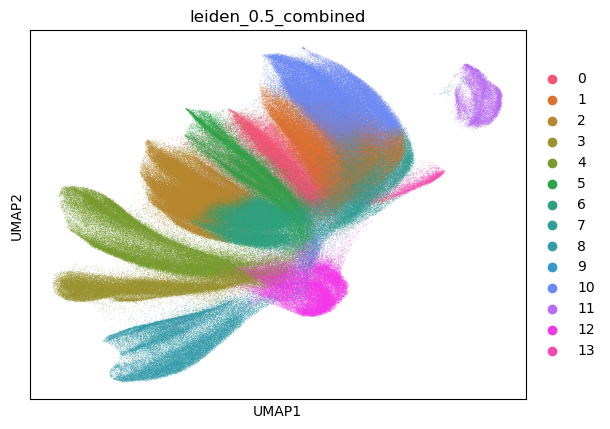

In [12]:
# Generate a palette with enough distinct colors for clusters
n_clusters = adata_filtered_combined.obs['leiden_0.5_combined'].nunique()
palette = sns.husl_palette(n_clusters, l=0.6, s=0.9)

sc.pl.umap(
    adata_filtered_combined,
    color="leiden_0.5_combined",
    palette=palette,
    s=0.5
)

2026-04-20 15:17:02 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-20 15:17:03 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-20 15:17:03 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-20 15:17:04 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-20 15:17:05 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

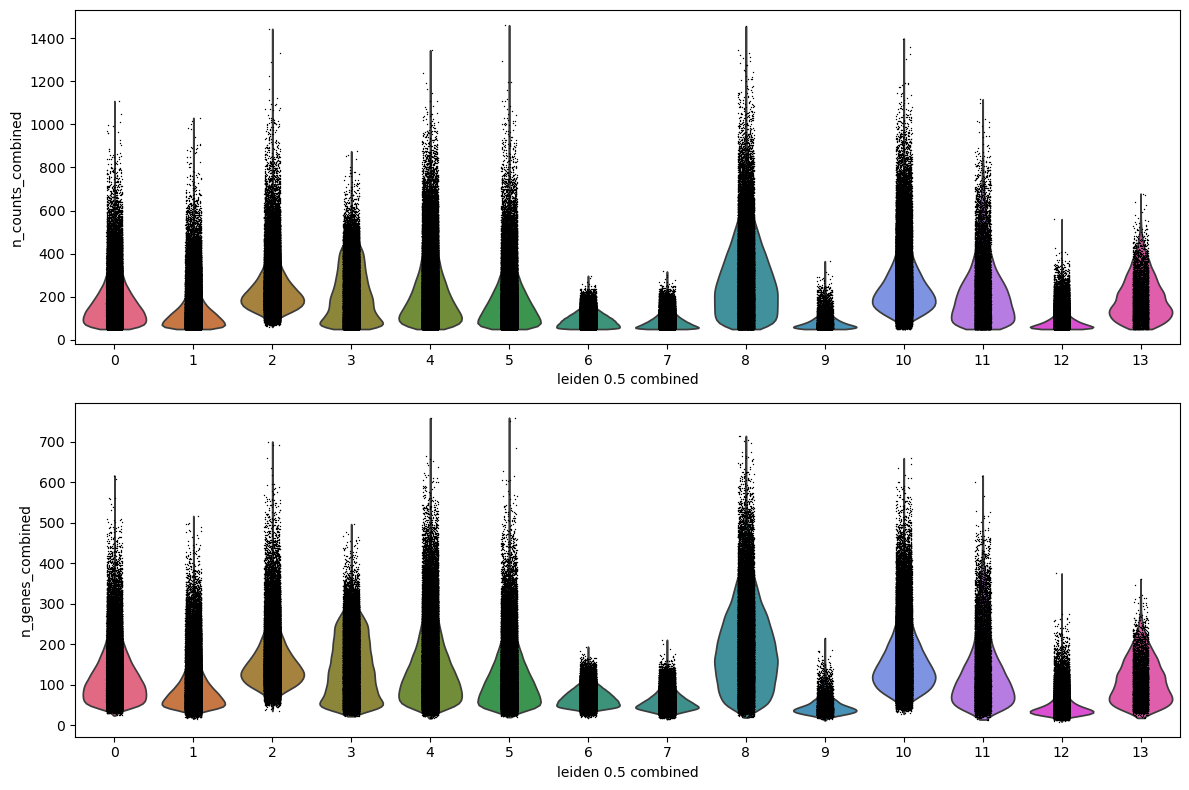

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# nCount violin
sc.pl.violin(adata_filtered_combined, keys="n_counts_combined", groupby="leiden_0.5_combined", 
             ax=axes[0], show=False)

# nFeature violin
sc.pl.violin(adata_filtered_combined, keys="n_genes_combined", groupby="leiden_0.5_combined", 
             ax=axes[1], show=False)

plt.tight_layout()
plt.show()

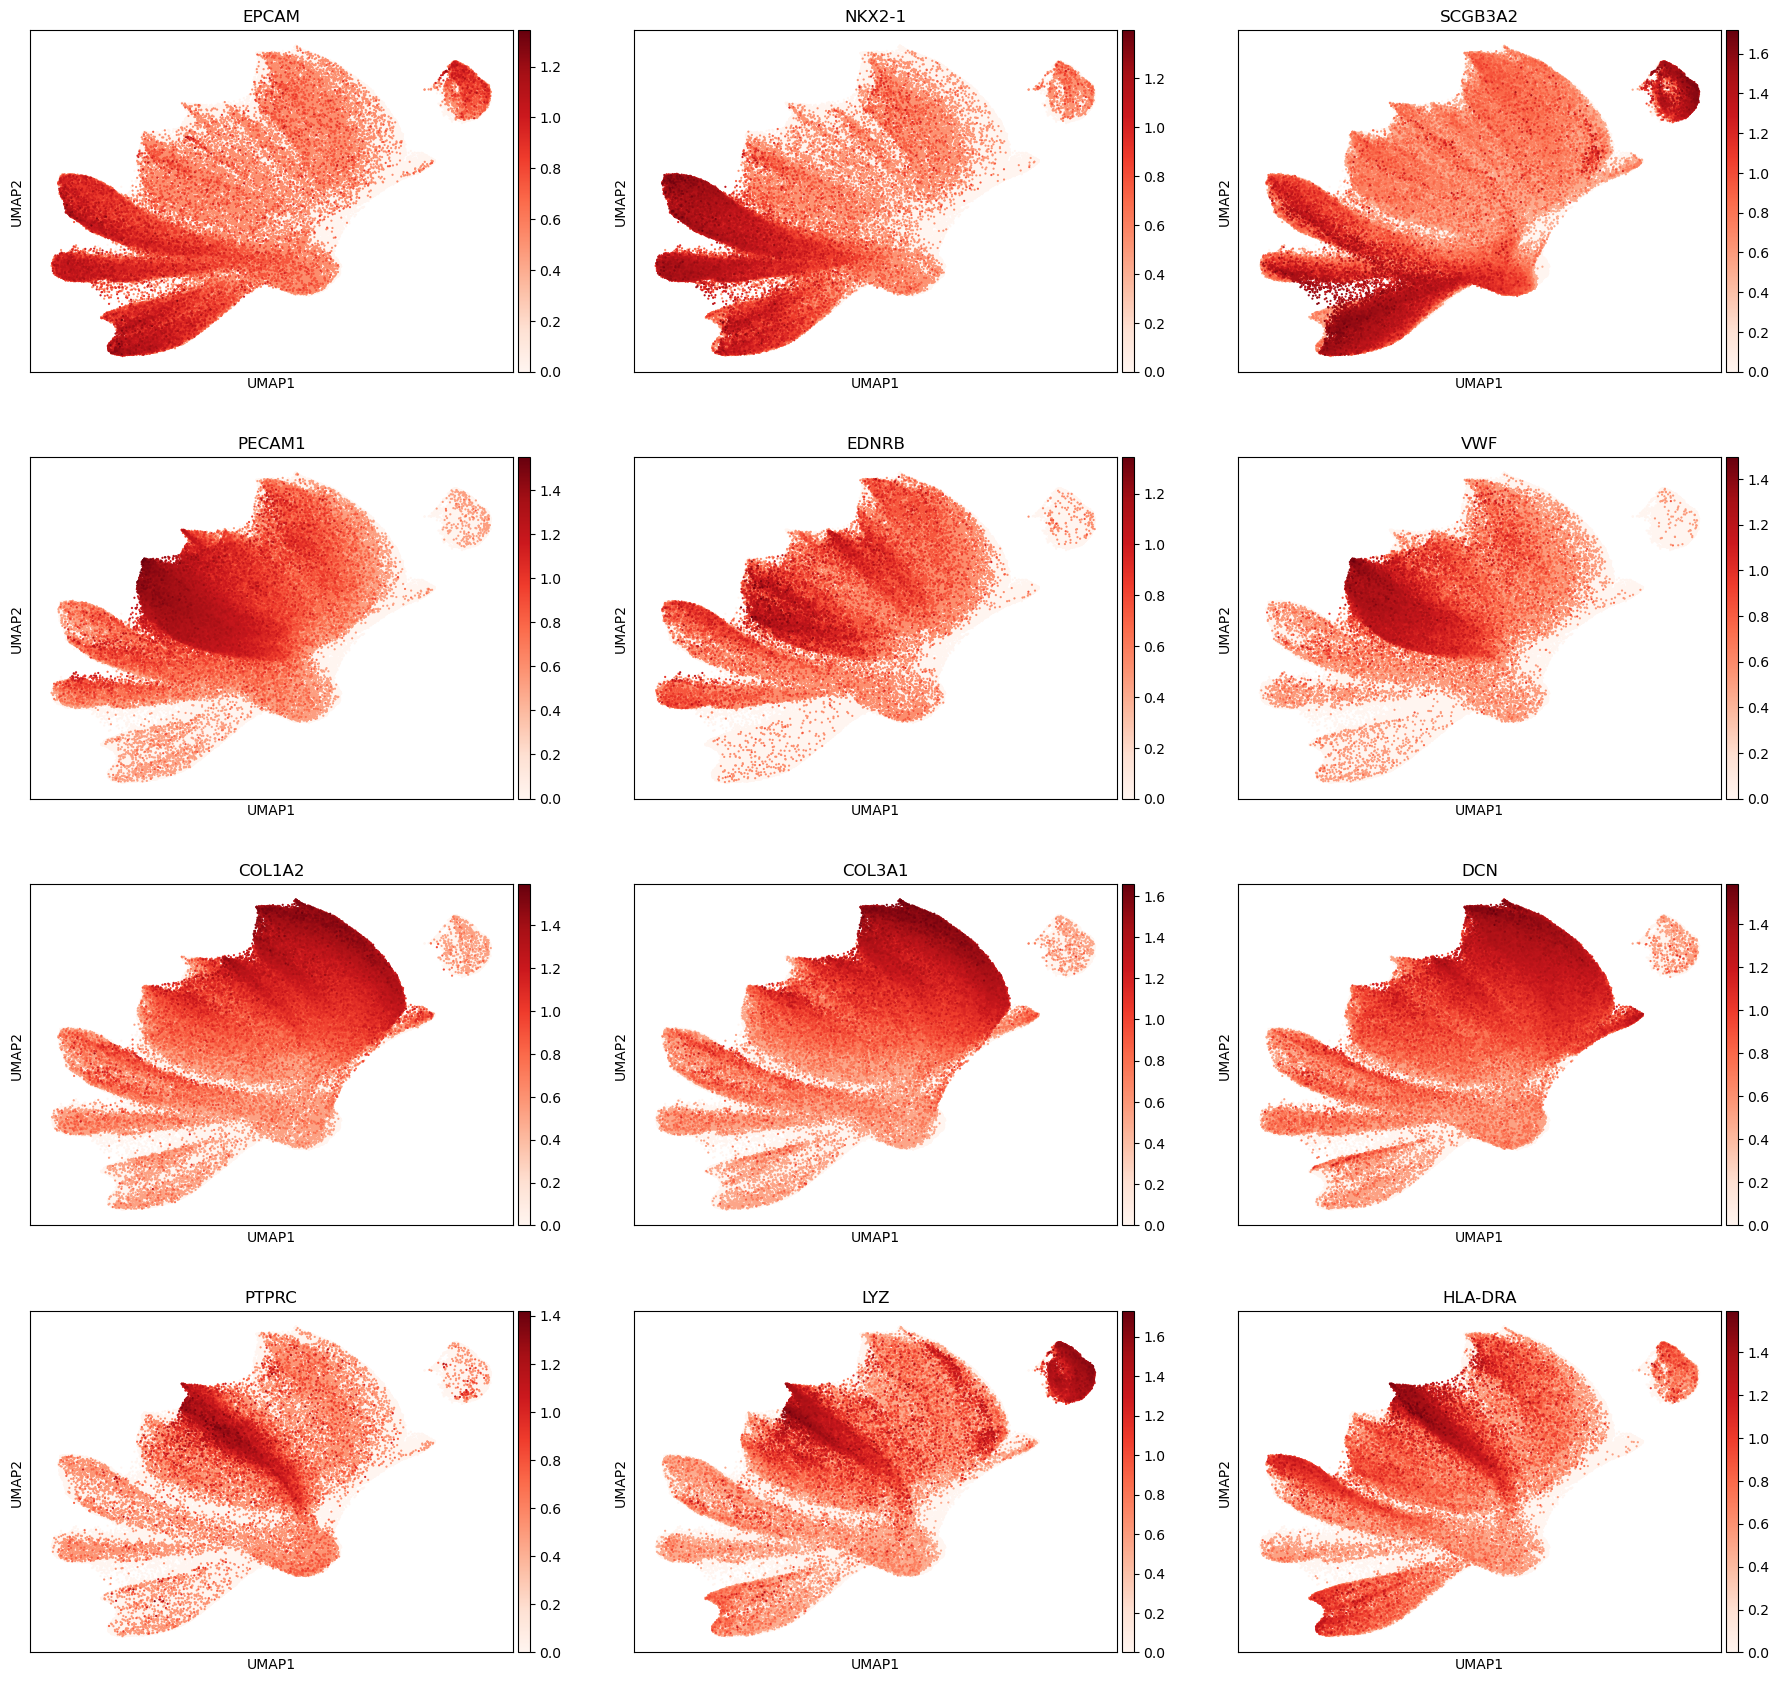

In [31]:
sc.pl.umap(adata_filtered_combined, 
           color=["EPCAM", "NKX2-1", "SCGB3A2",
                  "PECAM1", "EDNRB", "VWF",
                  "COL1A2", "COL3A1", "DCN",
                  "PTPRC", "LYZ", "HLA-DRA"], 
           cmap="Reds", 
           ncols=3, 
           size=10)

In [28]:
for gene in adata_filtered_combined.var_names:
    print(gene)

A2ML1
AAMP
AAR2
AARSD1
ABAT
ABCA1
ABCA3
ABCA4
ABCA7
ABCB1
ABCB4
ABCB6
ABCC1
ABCC12
ABCC2
ABCC3
ABCC4
ABCC6
ABCC8
ABCC9
ABCD1
ABCD3
ABCD4
ABCF3
ABCG1
ABCG2
ABHD11
ABHD6
ABI3
ABI3BP
ABL1
ABL2
ABO
ABTB1
ABTB2
ACAA2
ACACA
ACACB
ACAP1
ACAP2
ACAT1
ACE
ACE2
ACHE
ACKR3
ACLY
ACOD1
ACP5
ACPP
ACRBP
ACRV1
ACSL4
ACTBL2
ACTL6A
ACTL7A
ACTN1
ACTN2
ACTN4
ACVR1
ACVR1B
ACVR2A
ACVRL1
ACYP2
ADA
ADAM10
ADAM12
ADAM17
ADAM28
ADAM33
ADAM8
ADAM9
ADAMDEC1
ADAMTS1
ADAMTS12
ADAMTS19
ADAMTS2
ADAMTS4
ADAMTS5
ADAMTSL3
ADAR
ADCY2
ADCYAP1
ADCYAP1R1
ADD1
ADGRA1
ADGRA2
ADGRA3
ADGRB1
ADGRB2
ADGRD1
ADGRD2
ADGRE1
ADGRE2
ADGRE5
ADGRG5
ADGRG6
ADGRL1
ADGRL4
ADIPOQ
ADIPOR1
ADIPOR2
ADM
ADNP
ADORA1
ADORA2A
ADORA2B
ADORA3
ADRA1A
ADRA1B
ADRA1D
ADRA2A
ADRA2B
ADRA2C
ADRB1
ADRB2
ADRB3
ADTRP
AEBP1
AFAP1L2
AFF1
AFF2
AFG1L
AFM
AGAP1
AGAP3
AGER
AGMAT
AGO1
AGR3
AGRP
AGTR1
AGTR2
AGXT
AHCY
AHR
AHRR
AHSG
AICDA
AIF1L
AIFM1
AIM2
AIMP2
AIP
AIRE
AJAP1
AKAP11
AKAP4
AKAP8
AKR1B1
AKR1C3
AKT1
AKT2
AKT3
AKTIP
ALAD
ALCAM
ALDH1B1
ALDH2
ALDH3A2
ALDH7A1
A

In [ ]:
# Top markers
sc.tl.rank_genes_groups(adata_filtered_combined, groupby='leiden_0.5_combined', method='wilcoxon')

# View results
sc.pl.rank_genes_groups(adata_filtered_combined, n_genes=25, sharey=False)

results = []
for group in adata_filtered_combined.obs['leiden_0.5_combined'].unique():
    df = sc.get.rank_genes_groups_df(adata_filtered_combined, group=str(group))
    df['cluster'] = group
    
    # Get cells in group vs rest
    in_group = adata_filtered_combined.obs['leiden_0.5_combined'] == group
    
    # Calculate pct.1 (pct expressed in group)
    group_cells = adata_filtered_combined[in_group]
    df['pct.1'] = np.array(
        (group_cells[:, df['names'].values].X > 0).mean(axis=0)
    ).flatten()
    
    # Calculate pct.2 (pct expressed in rest)
    rest_cells = adata_filtered_combined[~in_group]
    df['pct.2'] = np.array(
        (rest_cells[:, df['names'].values].X > 0).mean(axis=0)
    ).flatten()
    
    # pct.diff
    df['pct.diff'] = df['pct.1'] - df['pct.2']
    
    results.append(df)

all_markers = pd.concat(results).reset_index(drop=True)

In [42]:
adata_filtered_combined.obs['Lineage'] = 'Low quality'
adata_filtered_combined.obs.loc[adata_filtered_combined.obs['leiden_0.5_combined'].isin(['3', '4', '8', '11']), 'Lineage'] = 'Epithelial'
adata_filtered_combined.obs.loc[adata_filtered_combined.obs['leiden_0.5_combined'].isin(['2', '6']), 'Lineage'] = 'Endothelial'
adata_filtered_combined.obs.loc[adata_filtered_combined.obs['leiden_0.5_combined'].isin(['0', '1', '7', '10', '13']), 'Lineage'] = 'Mesenchymal'
adata_filtered_combined.obs.loc[adata_filtered_combined.obs['leiden_0.5_combined'].isin(['5']), 'Lineage'] = 'Immune'

In [43]:
adata_filtered_combined.obs['Lineage'].value_counts()

Lineage
Mesenchymal    337159
Epithelial     190765
Endothelial    176810
Immune          60634
Low quality     50482
Name: count, dtype: int64

In [44]:
adata_filtered_combined

AnnData object with n_obs × n_vars = 815850 × 5481
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample', 'leiden_0.5_combined', 'leiden_1.0_combined', 'Lineage'
    var: 'name'
    uns: 'leiden_0.5_combined', 'leiden_1.0_combined', 'leiden_1.0_combined_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [45]:
epi_mes_adata_dual = adata_filtered_combined[adata_filtered_combined.obs['Lineage'].isin(['Epithelial', 'Mesenchymal'])]

In [47]:
epi_mes_adata_dual

AnnData object with n_obs × n_vars = 527924 × 5481
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample', 'leiden_0.5_combined', 'leiden_1.0_combined', 'Lineage'
    var: 'name'
    uns: 'leiden_0.5_combined', 'leiden_1.0_combined', 'leiden_1.0_combined_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [56]:
# Filtering out cells that aren't EPCAM+ or COL1A2+

def get_gene_counts(adata, gene_prefix):
      matches = [g for g in adata.var_names if g.startswith(gene_prefix)]
      idx = [adata.var_names.get_loc(g) for g in matches]                                                               
      counts = adata.layers['counts'][:, idx]
      if issparse(counts):                                                                                              
          counts = np.asarray(counts.todense())
      return counts.sum(axis=1)                                                                                         
   
epcam = get_gene_counts(epi_mes_adata_dual, 'EPCAM')                                                                  
col1a2 = get_gene_counts(epi_mes_adata_dual, 'COL1A2')
                                                                                                                        
is_epi = (epi_mes_adata_dual.obs['Lineage'] == 'Epithelial') & (epcam > 0)                                            
is_mes = (epi_mes_adata_dual.obs['Lineage'] == 'Mesenchymal') & (col1a2 > 0)                                          
                                                                                                                        
before = epi_mes_adata_dual.obs['Lineage'].value_counts().rename('before')                                            
epi_mes_adata_dual_filtered = epi_mes_adata_dual[is_epi | is_mes].copy()
after = epi_mes_adata_dual_filtered.obs['Lineage'].value_counts().rename('after')                                     
                       
summary = pd.concat([before, after], axis=1).assign(dropped=lambda x: x['before'] - x['after'])

In [57]:
summary

,before,after,dropped
Lineage,,,
Mesenchymal,337159,248196,88963
Epithelial,190765,102970,87795


In [63]:
epi_mes_adata_dual_filtered.layers['log1p'] = epi_mes_adata_dual_filtered.X.copy()

In [64]:
epi_mes_adata_dual_filtered.layers.keys()

KeysView(Layers with keys: counts, log1p)

In [65]:
epi_mes_adata_dual_filtered.write_h5ad("/scratch/smallapragada/v1_prime5k_comparison_finished_2026_01/objects/fishing_2lines_dualrun_5481genes_20pcs_epithelial_mesenchymal_2026_05_06.h5ad")

In [59]:
epi_mes_adata_dual_filtered

AnnData object with n_obs × n_vars = 351166 × 5481
    obs: 'matched_cell_ids', 'x_centroid_v1_prime', 'y_centroid_v1_prime', 'x_centroid_prime_v1_seg', 'y_centroid_prime_v1_seg', 'transcript_counts_v1_prime', 'transcript_counts_prime_v1_seg', 'cell_area', 'nucleus_area', 'nucleus_count', 'n_counts_prime_with_v1_seg', 'n_genes_prime_with_v1_seg', 'n_counts_v1_prime', 'n_genes_v1_prime', 'n_counts_combined', 'n_genes_combined', 'cell_id_original_v1_prime', 'sample', 'leiden_0.5_combined', 'leiden_1.0_combined', 'Lineage'
    var: 'name'
    uns: 'leiden_0.5_combined', 'leiden_1.0_combined', 'leiden_1.0_combined_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'